# Import Ground Truth

In [ ]:
from scipy.io import loadmat
from pathlib import Path

data_path = Path.cwd().parent / "data"

def get_ytrue(course, id):
    file_path = data_path / "toolbox1" / "Mizrahi" / f'{id}_{course}.mat'

    mat = loadmat(file_path, struct_as_record = False, squeeze_me = True)
    results = mat['results']

    if not hasattr(results, 'y'):
        ImportError(".mat file doesn't have the correct structure. Expected 'results' key.")
    
    y_true = results.y

    return y_true




SyntaxError: invalid syntax (564333549.py, line 5)

# Turning data into a N $\times$ 6 NumPy array

In [10]:
import numpy as np
import pandas as pd
from ins_tools.INS import INS
import ins_tools.visualize as visualize
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Load your experimental data
# Replace this with your actual DataFrame loading method
root = Path.cwd().parent
data_path = root / "data"

# print(type(root), type(data_path))

file_list = list(data_path.rglob("xsens.csv"))

file = file_list[0]

cols = ['acceleration_RightFoot_x', 'acceleration_RightFoot_y', 'acceleration_RightFoot_z', 'angularVelocity_RightFoot_x', 'angularVelocity_RightFoot_y', 'angularVelocity_RightFoot_z']

df = pd.read_csv(file, usecols = cols)
imu_array = df.to_numpy() # pyshoe expects an Nx6 numpy array in this specific order

In [ ]:
def calculate_zv_error(G_test, imu_data, ground_truth, detector_type):
    """
    The objective function. Calculates the total classification error for a given G.
    """
    # Initialize a fresh INS instance for each test
    # (Remember to set T to your actual sensor sampling period)
    ins = INS(imu_data, sigma_a=0.00098, sigma_w=8.7266463e-5, T=1.0/200)
    
    # Run the detector with the test threshold
    ins.baseline(W=5, G=G_test, detector=detector_type)
    
    # Extract the predicted binary sequence
    predicted_zv = ins.zv
    
    # Calculate error (Hamming distance / sum of absolute differences)
    error = np.sum(np.abs(predicted_zv - ground_truth))
    
    return error

for file in file_list:
    df = pd.read_csv(file, usecols = cols)
    imu_array = df.to_numpy()
    
    

AMVD (Acceleration Moving Variance Detector)
trusts only the accelerometer. (Useful if the sensor is mounted on a part of the foot that rotates slightly even when planted).
Running amvd zero-velocity detector...


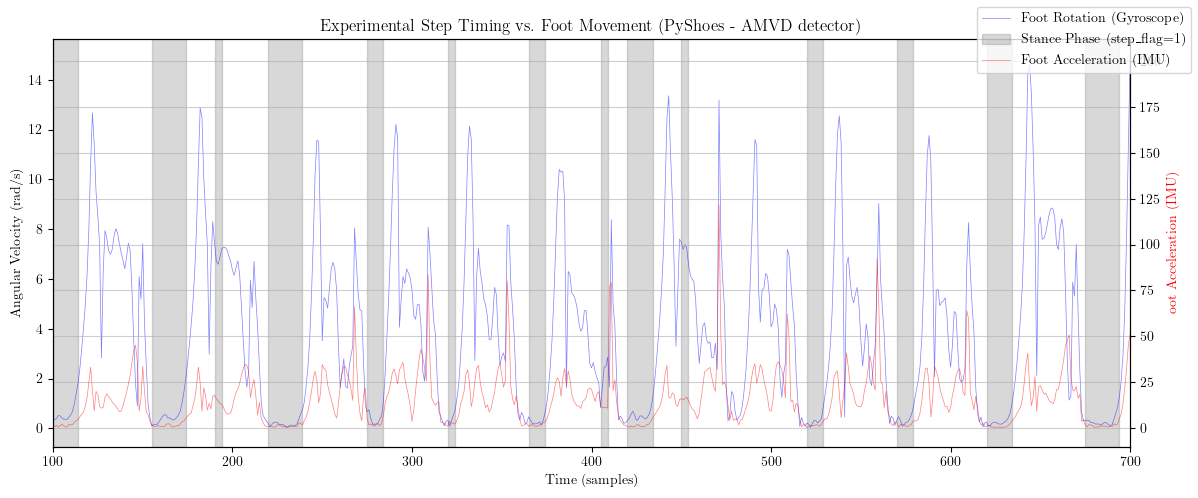

MBGTD (Magnitude-Based Generalized Test Detector)
trust both. They fuse the data streams for maximum robustness, but require careful tuning because a noise spike in either sensor can ruin the detection.
Running mbgtd zero-velocity detector...


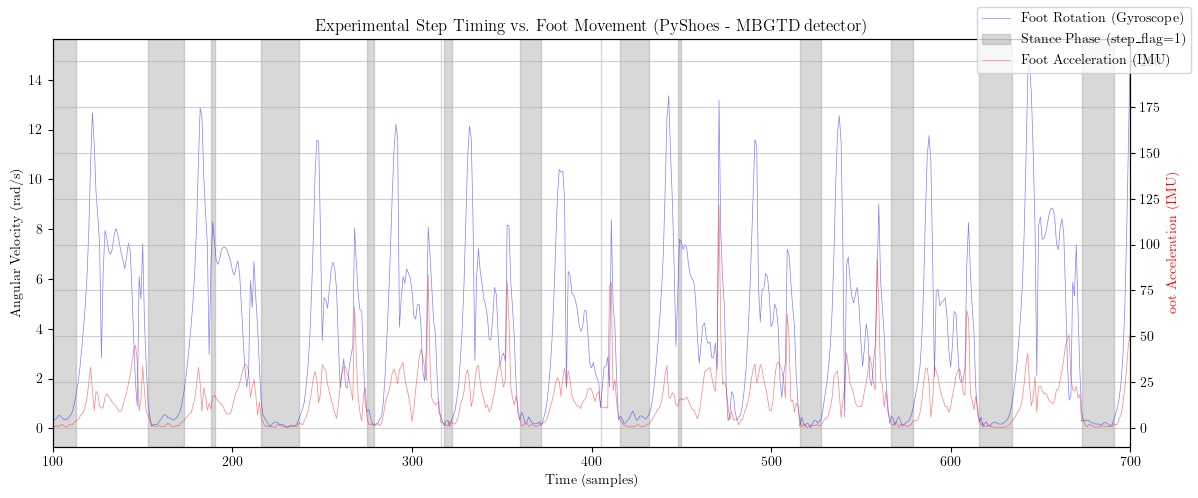

In [26]:

# 2. Extract into an Nx6 NumPy array
# Ensure the columns are strictly [Accel_X, Accel_Y, Accel_Z, Gyro_X, Gyro_Y, Gyro_Z]
imu_array = df[['acceleration_RightFoot_x', 'acceleration_RightFoot_y', 'acceleration_RightFoot_z', 'angularVelocity_RightFoot_x', 'angularVelocity_RightFoot_y', 'angularVelocity_RightFoot_z']].to_numpy()

# 3. Initialize the INS system
# IMPORTANT: Adjust 'T' to match the sampling period of your sensors!
# (e.g., if your IMU records at 100Hz, T=1.0/100)
ins = INS(imu_array, sigma_a=0.00098, sigma_w=8.7266463e-5, T=1.0/200)

def run_detector(detector_name):
    detector_name = detector_name.lower()
    if detector_name not in ['shoe', 'ared', 'amvd', 'mbgtd']:
        ValueError(f"{detector_name} is not a valid detector.\nThe available detectors are shoe, ared, amvd, mbgtd")

    specs = {
        'shoe': {"G":2e8, "description":"SHOE (Stance Hypothesis Optimal Estimation)\ntrust both. They fuse the data streams for maximum robustness, but require careful tuning because a noise spike in either sensor can ruin the detection."},
        'ared': {"G":2.0, "description":"ARED (Angular Rate Energy Detector)\ntrusts only the gyroscope. (Highly recommended if your accelerometer data is noisy)."},
        'amvd': {"G":7, "description":"AMVD (Acceleration Moving Variance Detector)\ntrusts only the accelerometer. (Useful if the sensor is mounted on a part of the foot that rotates slightly even when planted)."},
        'mbgtd': {"G":10, "description":"MBGTD (Magnitude-Based Generalized Test Detector)\ntrust both. They fuse the data streams for maximum robustness, but require careful tuning because a noise spike in either sensor can ruin the detection."},
    }

    # 4. Run the Classical Detector
    print(specs[detector_name]['description'])
    print(f"Running {detector_name} zero-velocity detector...")
    ins.baseline(W=5, G=specs[detector_name]['G'], detector=detector_name)

    # 5. Extract Step Timing (Zero-Velocity Flags)
    # pyshoe stores the calculated binary sequence in the 'zv' attribute
    step_flags = ins.zv 

    # Let's visualize the step timing instead of the 2D space
    import matplotlib.pyplot as plt
    import numpy as np

    # Calculate the magnitude of the gyroscope to easily see foot rotation
    gyro_magnitude = np.linalg.norm(imu_array[:, 3:6], axis=1)
    acc_magnitude = np.linalg.norm(imu_array[:, 0:3], axis=1)

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Plot the physical movement of the foot
    ax1.plot(gyro_magnitude, label='Foot Rotation (Gyroscope)', color='blue', alpha=0.5, linewidth = 0.5)
        
    # --- NEW SHADING LOGIC ---
    # Create an array of x-coordinates (sample indices)
    x = np.arange(len(step_flags))
    
    # Shade the background gray where step_flags == 1
    # transform=ax1.get_xaxis_transform() makes y=0 the bottom of the plot and y=1 the top
    ax1.fill_between(x, 0, 1, where=(step_flags == 1), color='gray', alpha=0.3, 
                     transform=ax1.get_xaxis_transform(), label='Stance Phase (step_flag=1)')
    # -------------------------


    ax1.set_ylabel('Angular Velocity (rad/s)')
    ax1.set_xlabel('Time (samples)')
    ax1.set_xlim(100,700)

    # Overlay the algorithm's Stance Phase detection
    ax2 = ax1.twinx()
    ax2.plot(acc_magnitude, label='Foot Acceleration (IMU)', color='red', alpha=0.5, linewidth = 0.5)
    ax2.set_ylabel('oot Acceleration (IMU)', color='red')

    # 1. Extract handles and labels from each axis
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    # 2. Combine them
    all_handles = handles1 + handles2
    all_labels = labels1 + labels2

    plt.title(f"Experimental Step Timing vs. Foot Movement (PyShoes - {detector_name.upper()} detector)")
    fig.legend(all_handles, all_labels)
    plt.grid(True, alpha=0.6)
    fig.tight_layout()
    plt.show()

for detector in ['amvd', 'mbgtd']:
    run_detector(detector)

AMVD (Acceleration Moving Variance Detector)
trusts only the accelerometer. (Useful if the sensor is mounted on a part of the foot that rotates slightly even when planted).
Running amvd zero-velocity detector...


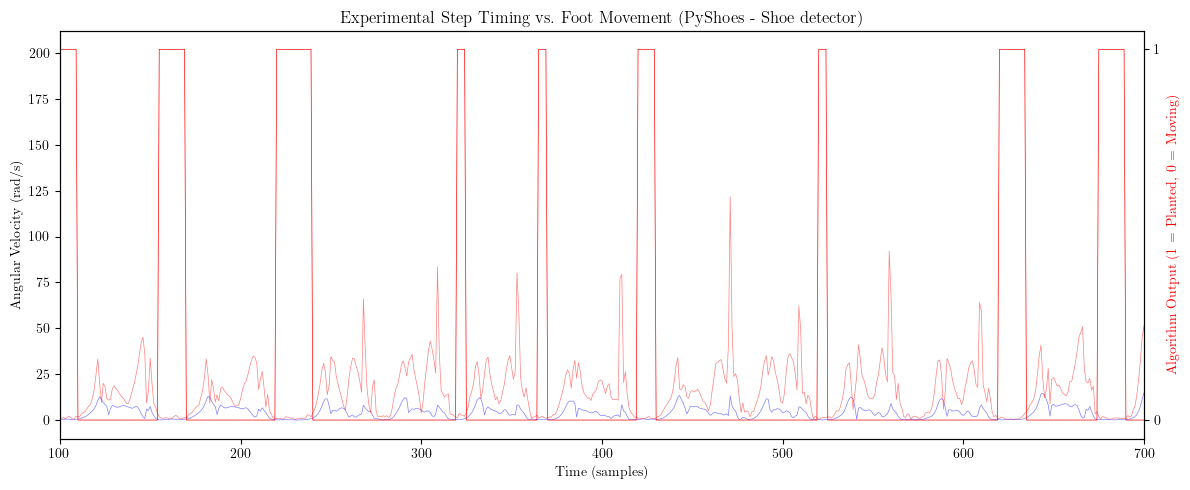

MBGTD (Magnitude-Based Generalized Test Detector)
trust both. They fuse the data streams for maximum robustness, but require careful tuning because a noise spike in either sensor can ruin the detection.
Running mbgtd zero-velocity detector...


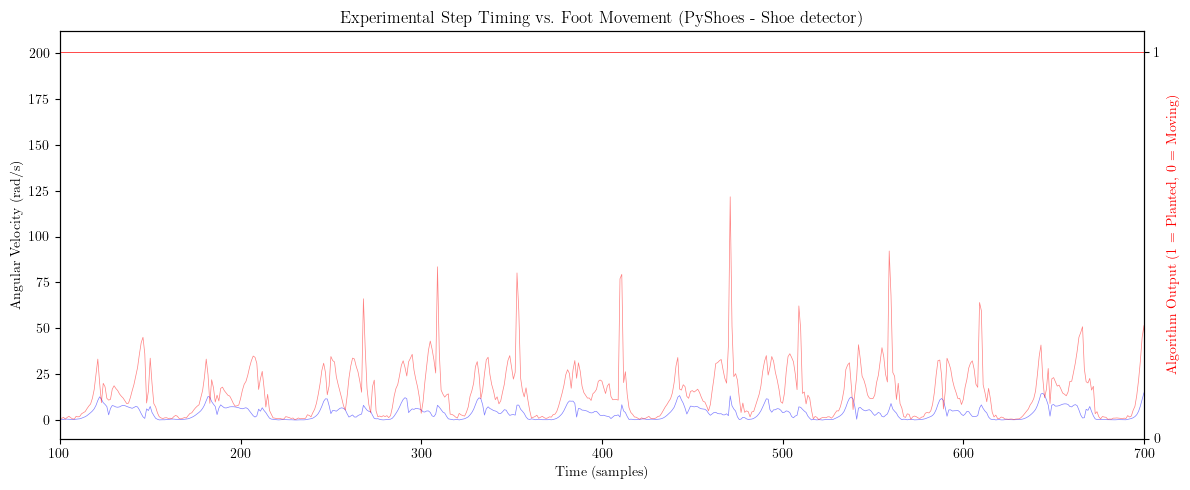

In [18]:

for detector in ['amvd', 'mbgtd']:
    run_detector(detector)